In [ ]:
# Required dependencies for QLoRA fine-tuning
# !pip install -U bitsandbytes trl
# !pip install -q accelerate==0.31.0 peft==0.11.1 bitsandbytes==0.43.1 transformers==4.41.2 trl==0.9.4 sentencepiece==0.2.0 triton==3.1.0

## Overview

This notebook implements QLoRA (Quantized Low-Rank Adaptation) for efficient fine-tuning of large language models. QLoRA combines two key techniques:

1. **4-bit Quantization**: Reduces memory usage by storing model weights in 4-bit precision
2. **LoRA (Low-Rank Adaptation)**: Adds trainable low-rank matrices to specific layers while keeping the base model frozen

**Key Benefits:**
- Enables fine-tuning of large models on consumer GPUs
- Significantly reduces memory requirements (up to 75% reduction)
- Maintains model performance while using fewer trainable parameters
- Faster training compared to full fine-tuning

**Process Flow:**
1. Load and preprocess conversational dataset
2. Configure 4-bit quantization settings
3. Set up LoRA adaptation parameters
4. Train with supervised fine-tuning (SFT)
5. Merge adapter with base model
6. Evaluate performance


# Fine-Tuning Language Models with QLoRA

This notebook demonstrates how to fine-tune a language model using QLoRA (Quantized Low-Rank Adaptation), a parameter-efficient fine-tuning technique that enables training large language models on consumer hardware by combining 4-bit quantization with LoRA adapters.

## Data Preparation and Preprocessing

We'll use the UltraChat dataset, which contains high-quality conversational data suitable for training chat models. The dataset is preprocessed and split into training, validation, and test sets.

In [ ]:
from datasets import load_dataset

# Load and sample UltraChat dataset for demonstration
dataset = (
    load_dataset("HuggingFaceH4/ultrachat_200k",  split="test_sft")
      .shuffle(seed=42)
      .select(range(3_000))  # Use 3k samples for faster training
)

def preprocess(example):
    messages = example["messages"]
    return {"messages": messages}

processed = dataset.map(preprocess)

cols_to_drop = [c for c in ["prompt", "prompt_id"] if c in processed.column_names]
processed = processed.remove_columns(cols_to_drop)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train_sft-00000-of-00003-a3ecf92756(…):   0%|          | 0.00/244M [00:00<?, ?B/s]

data/train_sft-00001-of-00003-0a1804bcb6(…):   0%|          | 0.00/244M [00:00<?, ?B/s]

data/train_sft-00002-of-00003-ee46ed25cf(…):   0%|          | 0.00/244M [00:00<?, ?B/s]

...

Generating train_sft split:   0%|          | 0/207865 [00:00<?, ? examples/s]

Generating test_sft split:   0%|          | 0/23110 [00:00<?, ? examples/s]

Generating train_gen split:   0%|          | 0/256032 [00:00<?, ? examples/s]

Generating test_gen split:   0%|          | 0/28304 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

In [ ]:
# Create train/validation/test splits
total_size = len(processed)
train_size = int(0.7 * total_size)    # 70% for training
eval_size = int(0.15 * total_size)    # 15% for validation
test_size = total_size - train_size - eval_size  # 15% for testing

train_dataset = processed.select(range(train_size))
eval_dataset = processed.select(range(train_size, train_size + eval_size))
test_dataset = processed.select(range(train_size + eval_size, total_size))

print(f"Training examples: {len(train_dataset)}")
print(f"Evaluation examples: {len(eval_dataset)}")
print(f"Test examples: {len(test_dataset)}")
print(f"Sample eval example: {eval_dataset[0]['messages']}")

Training examples: 2100
Evaluation examples: 450
Test examples: 450
Sample eval example: [{'content': 'Can you recommend a specific National Park for families with young children and suggest some kid-friendly activities?', 'role': 'user'}, {'content': "Yes, I can recommend Yosemite National Park for families with young children. Some kid-friendly activities include:\n\n1. Junior Ranger Program: Children can participate in this program to learn about the park's history, wildlife, and conservation efforts while earning a badge.\n\n2. Nature Walks: There are several short and easy hiking trails in Yosemite, such as the one at the Tuolumne Grove of Giant Sequoias, which is perfect for families with young children.\n\n3. Bridalveil Fall: This is a popular waterfall in Yosemite that is easy to access and has a short hiking trail. It's a great place for kids to explore and take photos.\n\n4. Valley Visitor Center: You can visit the Valley Visitor Center to learn about the park's history and p

## Model Loading and Quantization

We load the base model with 4-bit quantization using BitsAndBytesConfig. This significantly reduces memory usage while maintaining model performance, enabling fine-tuning on consumer GPUs.

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

model_name = "TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T"

# 4-bit quantization configuration
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",  # Normal float 4-bit quantization
    bnb_4bit_compute_dtype="float16",
    bnb_4bit_use_double_quant=True,  # Nested quantization for additional memory savings
)

# Load the model with quantization
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    quantization_config=bnb_config,
)
model.config.use_cache = False
model.config.pretraining_tp = 1

# Load LLaMA tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=False)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

config.json:   0%|          | 0.00/560 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/4.40G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/129 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/776 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

## LoRA Configuration

LoRA (Low-Rank Adaptation) enables efficient fine-tuning by adding trainable low-rank matrices to specific model layers. This approach significantly reduces the number of trainable parameters while maintaining performance.

In [ ]:
from peft import LoraConfig

target_modules= ['k_proj', 'gate_proj', 'v_proj', 'up_proj', 'q_proj', 'o_proj', 'down_proj']

peft_config = LoraConfig(
    lora_alpha=32,  # LoRA scaling parameter
    lora_dropout=0.1,  # Dropout rate for LoRA layers
    r=64,  # Rank of adaptation matrices
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=target_modules
)

## Training Configuration

Configuration for supervised fine-tuning with evaluation monitoring, model checkpointing, and Weights & Biases integration for experiment tracking.

In [ ]:
from trl import SFTConfig

output_dir = "output"
training_arguments = SFTConfig(
    output_dir=output_dir,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    max_length=512,
    gradient_accumulation_steps=4,
    optim="paged_adamw_32bit",
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    num_train_epochs=3,

    # Evaluation settings
    eval_strategy="steps",
    eval_steps=25,
    logging_steps=10,

    # Model checkpointing
    save_strategy="steps",
    save_steps=50,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    fp16=True,
    gradient_checkpointing=True,
    chat_template_path="TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    eos_token="</s>",

    # Experiment tracking
    report_to="wandb",
    run_name="tinyllama-qlora-with-eval",
)

## Model Training

Initialize the SFT trainer with early stopping and begin the fine-tuning process. The trainer will monitor validation loss and save the best performing checkpoint.

In [ ]:
from trl import SFTTrainer
from transformers import EarlyStoppingCallback

trainer = SFTTrainer(
    model=model,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    args=training_arguments,
    processing_class=tokenizer,
    peft_config=peft_config,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=3,
            early_stopping_threshold=0.001
        )
    ]
)

# Train the model
trainer.train()

# Save the final model
trainer.model.save_pretrained("TinyLlama-1.1B-qlora-adapter")
tokenizer.save_pretrained("TinyLlama-1.1B-qlora-adapter")

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

Tokenizing train dataset:   0%|          | 0/2100 [00:00<?, ? examples/s]

...

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: maya-sam (maya-sam-mayaai) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
25,1.447500,1.480610,1.541278,101184.000000,0.644358
50,1.448700,1.452686,1.510742,202048.000000,0.649186
75,1.354300,1.435866,1.492361,303524.000000,0.652099
100,1.499400,1.425786,1.471533,404899.000000,0.653981
125,1.423200,1.420494,1.449943,506578.000000,0.654265
150,1.392200,1.415990,1.484813,608026.000000,0.655259
175,1.400600,1.411688,1.424095,709150.000000,0.656099
200,1.435500,1.408333,1.459870,810827.000000,0.656720
225,1.406700,1.404987,1.433347,911215.000000,0.656720
250,1.341000,1.401525,1.445705,1012912.000000,0.657751


('TinyLlama-1.1B-qlora-adapter/tokenizer_config.json',
 'TinyLlama-1.1B-qlora-adapter/special_tokens_map.json',
 'TinyLlama-1.1B-qlora-adapter/chat_template.jinja',
 'TinyLlama-1.1B-qlora-adapter/tokenizer.model',
 'TinyLlama-1.1B-qlora-adapter/added_tokens.json',
 'TinyLlama-1.1B-qlora-adapter/tokenizer.json')

## Model Merging

Merge the trained LoRA adapter with the base model to create a single, deployable model. This combines the original model weights with the learned adaptations.

In [9]:
from peft import AutoPeftModelForCausalLM

model = AutoPeftModelForCausalLM.from_pretrained(
    "TinyLlama-1.1B-qlora-adapter",
    low_cpu_mem_usage=True,
    device_map="auto",
)

# Merge LoRA and base model
merged_model = model.merge_and_unload()

## Model Evaluation

Evaluate the fine-tuned model by generating responses to test examples and analyzing training metrics. This provides insights into model performance and training effectiveness.

In [ ]:
import torch
from transformers import pipeline

def evaluate_model_generation(model, tokenizer, dataset, num_samples=3):
    """
    Generate responses for evaluation examples to assess model quality.
    
    Args:
        model: The fine-tuned model
        tokenizer: Model tokenizer
        dataset: Evaluation dataset
        num_samples: Number of samples to evaluate
    """
    print("=" * 50)
    print("EVALUATION GENERATION SAMPLES")
    print("=" * 50)

    # Create a pipeline for text generation
    pipe = pipeline("text-generation", model=model, tokenizer=tokenizer)

    for i in range(min(num_samples, len(dataset))):
        # Extract conversation messages
        messages = dataset[i]['messages']

        # Separate user and assistant messages
        user_messages = [msg for msg in messages if msg['role'] == 'user']
        assistant_messages = [msg for msg in messages if msg['role'] == 'assistant']

        if user_messages:
            user_content = user_messages[0]['content']
            prompt = f"<|user|>\n{user_content}</s>\n<|assistant|>\n"

            # Generate model response
            with torch.no_grad():
                response = pipe(prompt, max_new_tokens=150, do_sample=True, temperature=0.7, pad_token_id=tokenizer.eos_token_id)
                generated_text = response[0]['generated_text']

                # Extract and clean assistant response
                assistant_response = generated_text.split("<|assistant|>\n")[-1]
                assistant_response = assistant_response.replace("</s>", "").strip()

            print(f"\nSample {i+1}:")
            print(f"User: {user_content[:150]}{'...' if len(user_content) > 150 else ''}")
            print(f"Generated: {assistant_response[:300]}{'...' if len(assistant_response) > 300 else ''}")

            # Display expected response for comparison
            if assistant_messages:
                expected = assistant_messages[0]['content']
                print(f"Expected: {expected[:150]}{'...' if len(expected) > 150 else ''}")

            print("-" * 30)

Device set to use cuda:0


Evaluating the final model...
EVALUATION GENERATION SAMPLES

Sample 1:
User: How to make a traditional Chinese hot pot at home?
Generated: 1. Choose the right pot: a pot with a narrow base is best for holding in hot water to cook food, while one with a larger base is better for serving.

2. Choose the right ingredients: hot pot takes more ingredients than a traditional Chinese soup because there are more items that need to be cooked at...
Expected: Ingredients:
- Meat (thinly sliced beef, lamb, pork, or chicken)
- Seafood (shrimp, squid, fish)
- Vegetables (mushrooms, bok choy, Chinese cabbage, l...
------------------------------

Sample 2:
User: Design and conduct interactive digital prep classes for both verbal and quantitative sections of standardized exams like SATs, incorporating a variety...
Generated: 1. Create a learning platform that allows students to practice online with video lectures and quizzes.

2. Provide individualized feedback and personalized practice sessions for ea

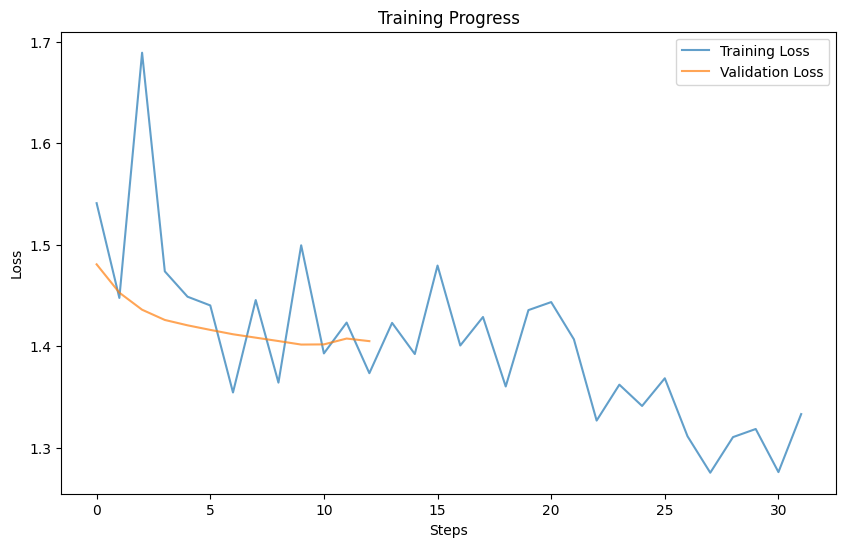

Final training loss: 1.3330
Final validation loss: 1.4049


In [ ]:
# Evaluate the fine-tuned model
print("Evaluating the final model...")
evaluate_model_generation(merged_model, tokenizer, test_dataset, num_samples=5)

# Analyze training history
if hasattr(trainer, 'state') and hasattr(trainer.state, 'log_history'):
    import matplotlib.pyplot as plt

    # Extract losses
    train_losses = [log['loss'] for log in trainer.state.log_history if 'loss' in log]
    eval_losses = [log['eval_loss'] for log in trainer.state.log_history if 'eval_loss' in log]

    # Plot training progress
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Training Loss', alpha=0.7)
    plt.plot(eval_losses, label='Validation Loss', alpha=0.7)
    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.title('Training Progress')
    plt.legend()
    plt.show()

    print(f"Final training loss: {train_losses[-1]:.4f}")
    print(f"Final validation loss: {eval_losses[-1]:.4f}")

## Model Inference

Test the fine-tuned model with a simple prompt to demonstrate its conversational capabilities.

In [ ]:
from transformers import pipeline

# Test prompt using chat template
prompt = """<|user|>
Tell me something about cats.</s>
<|assistant|>
"""

# Generate response using the fine-tuned model
pipe = pipeline(task="text-generation", model=merged_model, tokenizer=tokenizer)
print(pipe(prompt)[0]["generated_text"])

Device set to use cuda:0


<|user|>
Tell me something about cats.</s>
<|assistant|>
Cats are cute, cuddly, and gentle creatures. They are known for their affectionate and playful nature, and are often considered the nation’s favorite pet. They are also known for their intelligence and curiosity, making them a great companion for any family.
